=== Cấu trúc Train Dataset ===
Số mẫu: 6499
Số đặc trưng (bao gồm target và id): 24

Kiểu dữ liệu các cột:
id                           int64
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Thông tin tổng quan:
<class 'pandas.co

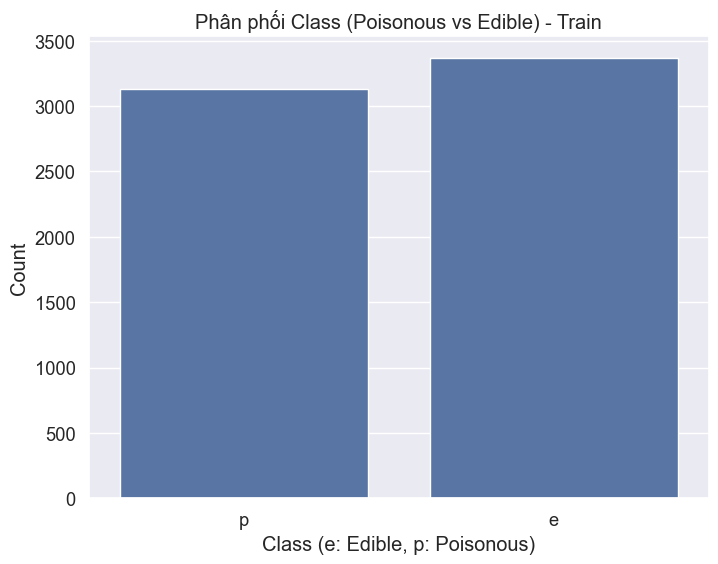


=== Chú thích ===
Dataset không có đặc trưng số, do đó không thực hiện thống kê mô tả, histogram hoặc boxplot.


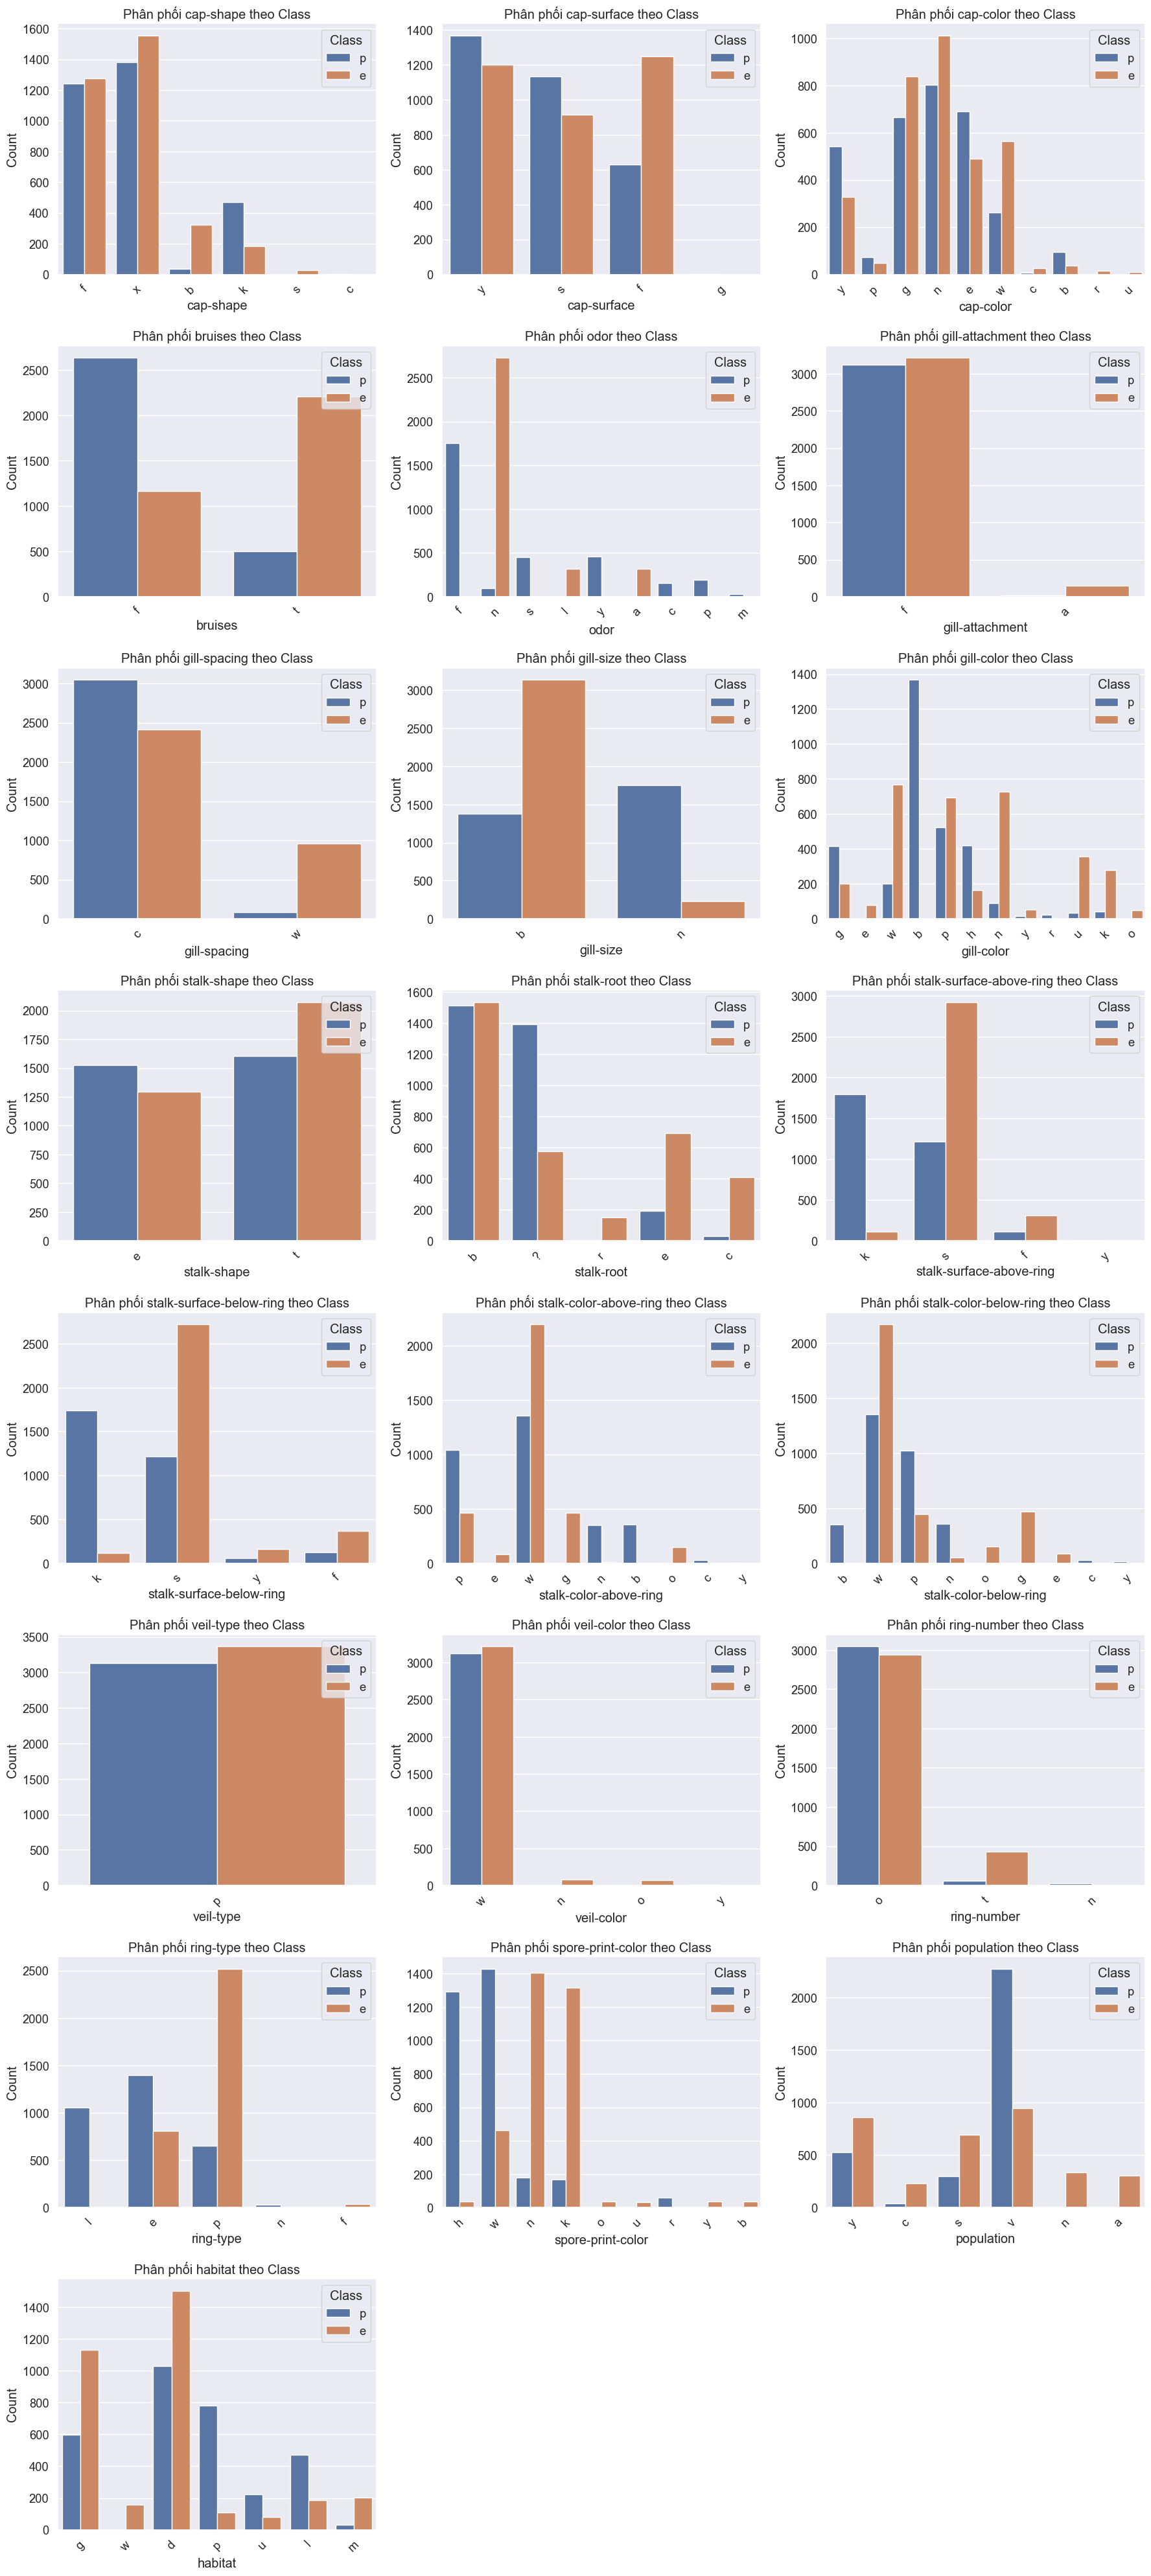


=== Phân tích dữ liệu thiếu (Train) ===
stalk-root    1968
dtype: int64

=== Phân tích dữ liệu thiếu (Test) ===
stalk-root    512
dtype: int64

=== Phân tích Missing theo Class (Train) ===
class
e     575
p    1393
dtype: int64


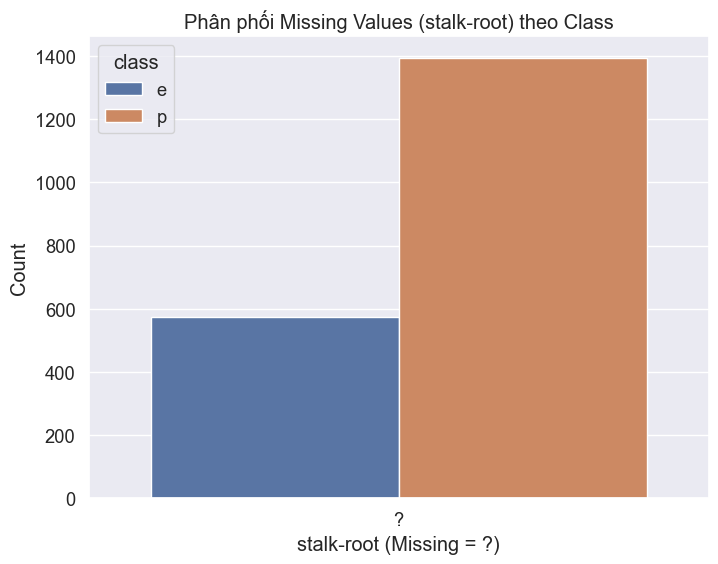


=== Phân tích mối quan hệ (Chi-square test) ===

P-values từ Chi-square test (thấp hơn = đặc trưng quan trọng hơn):
                                p-value
bruises                    0.000000e+00
odor                       0.000000e+00
gill-size                  0.000000e+00
stalk-color-below-ring     0.000000e+00
stalk-surface-below-ring   0.000000e+00
stalk-color-above-ring     0.000000e+00
stalk-surface-above-ring   0.000000e+00
gill-color                 0.000000e+00
ring-type                  0.000000e+00
population                 0.000000e+00
spore-print-color          0.000000e+00
habitat                   6.821749e-262
stalk-root                1.026436e-234
gill-spacing              1.378342e-173
cap-shape                  2.559084e-81
ring-number                1.162505e-64
cap-color                  3.053189e-59
cap-surface                2.131891e-50
veil-color                 1.121402e-31
gill-attachment            8.164420e-25
stalk-shape                7.247029e-17
vei

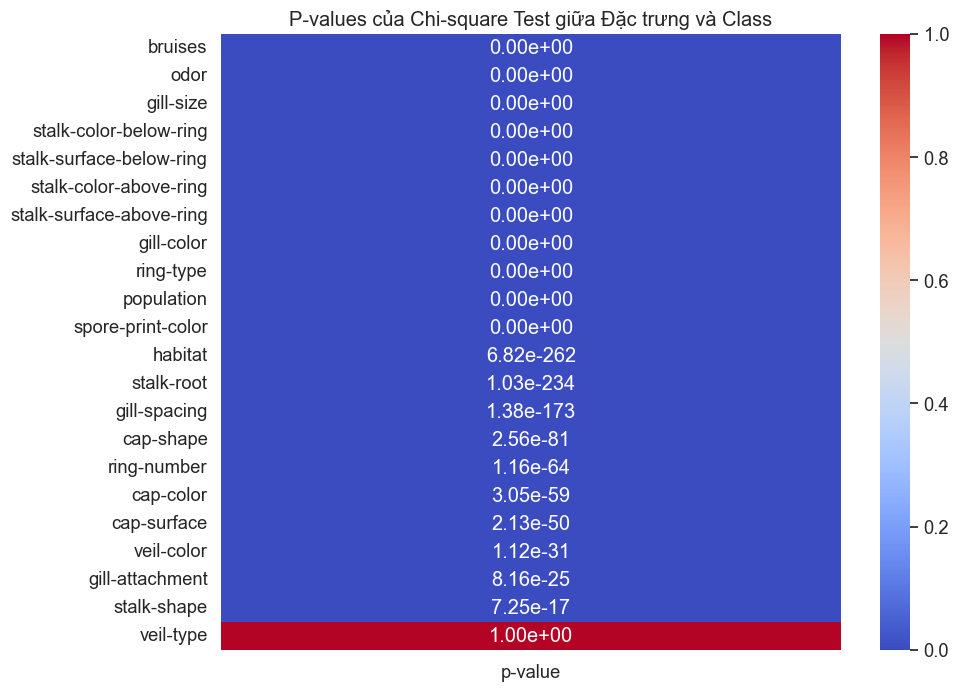


=== Số giá trị unique của từng đặc trưng (Train) ===
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# Thiết lập style cho biểu đồ
sns.set(font_scale=1.2)

# 1. Load dữ liệu
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Kiểm tra cấu trúc dữ liệu
print("=== Cấu trúc Train Dataset ===")
print(f"Số mẫu: {train_df.shape[0]}")
print(f"Số đặc trưng (bao gồm target và id): {train_df.shape[1]}")
print("\nKiểu dữ liệu các cột:")
print(train_df.dtypes)
print("\nThông tin tổng quan:")
print(train_df.info())

print("\n=== Cấu trúc Test Dataset ===")
print(f"Số mẫu: {test_df.shape[0]}")
print(f"Số đặc trưng (bao gồm target và id): {test_df.shape[1]}")
print("\nKiểu dữ liệu các cột:")
print(test_df.dtypes)

# 3. Phân tích biến mục tiêu (class)
print("\n=== Phân phối biến mục tiêu (class) trong Train ===")
print(train_df['class'].value_counts(normalize=True))
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=train_df)
plt.title('Phân phối Class (Poisonous vs Edible) - Train')
plt.xlabel('Class (e: Edible, p: Poisonous)')
plt.ylabel('Count')
plt.savefig('class_distribution.png')
plt.show()

# 4. Phân tích đặc trưng
# Chú thích: Không có đặc trưng số (numerical), chỉ có categorical
print("\n=== Chú thích ===")
print("Dataset không có đặc trưng số, do đó không thực hiện thống kê mô tả, histogram hoặc boxplot.")

# Phân tích đặc trưng phân loại
categorical_cols = train_df.drop(columns=['class', 'id']).columns
n_cols = 3  # Số cột trong lưới subplot
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='class', data=train_df, ax=axes[i])
    axes[i].set_title(f'Phân phối {col} theo Class')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Class', loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

# Xóa các subplot trống
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_features_distribution.png')
plt.show()

# 5. Phân tích dữ liệu thiếu (missing)
print("\n=== Phân tích dữ liệu thiếu (Train) ===")
missing_train = train_df.replace('?', np.nan).isnull().sum()
print(missing_train[missing_train > 0])

print("\n=== Phân tích dữ liệu thiếu (Test) ===")
missing_test = test_df.replace('?', np.nan).isnull().sum()
print(missing_test[missing_test > 0])

# Phân tích missing theo class
print("\n=== Phân tích Missing theo Class (Train) ===")
missing_by_class = train_df[train_df['stalk-root'] == '?'].groupby('class').size()
print(missing_by_class)
plt.figure(figsize=(8, 6))
sns.countplot(x='stalk-root', hue='class', data=train_df[train_df['stalk-root'] == '?'])
plt.title('Phân phối Missing Values (stalk-root) theo Class')
plt.xlabel('stalk-root (Missing = ?)')
plt.ylabel('Count')
plt.savefig('missing_stalk_root_by_class.png')
plt.show()

# 6. Phân tích mối quan hệ: Chi-square test thay cho ma trận tương quan
print("\n=== Phân tích mối quan hệ (Chi-square test) ===")
chi2_results = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(train_df[col], train_df['class'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    chi2_results[col] = p

# Chuyển kết quả chi-square thành DataFrame
chi2_df = pd.DataFrame.from_dict(chi2_results, orient='index', columns=['p-value'])
chi2_df = chi2_df.sort_values(by='p-value')

# In kết quả
print("\nP-values từ Chi-square test (thấp hơn = đặc trưng quan trọng hơn):")
print(chi2_df)

# Vẽ heatmap cho p-values
plt.figure(figsize=(10, 8))
sns.heatmap(chi2_df, annot=True, cmap='coolwarm', fmt='.2e')
plt.title('P-values của Chi-square Test giữa Đặc trưng và Class')
plt.savefig('chi2_pvalues_heatmap.png')
plt.show()

# 7. Phân tích giá trị unique của các đặc trưng
print("\n=== Số giá trị unique của từng đặc trưng (Train) ===")
unique_counts = train_df.drop(columns=['id']).nunique()
print(unique_counts)

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from scipy.stats import chi2_contingency

# Tải dữ liệu từ tệp CSV
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Lưu lại cột 'id' của test_df để tạo file submission sau này
test_ids = test_df['id']

print("Cột trong train_df:", list(train_df.columns))
print("Cột trong test_df:", list(test_df.columns))

# 1. Xử lý missing values
train_df['stalk-root'] = train_df['stalk-root'].replace('?', train_df['stalk-root'].mode()[0])
test_df['stalk-root'] = test_df['stalk-root'].replace('?', test_df['stalk-root'].mode()[0])

# 2. Loại bỏ cột không cần thiết
columns_to_drop = ['veil-type', 'veil-color', 'id']
columns_to_drop = [col for col in columns_to_drop if col in train_df.columns]
train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])

# 3. Tách features và target
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df # test_df không có cột 'class'

# Chú thích: Không có đặc trưng số nên bỏ qua chuẩn hóa/scale
print("Chú thích: Dataset không có đặc trưng số, bỏ qua bước chuẩn hóa/scale (StandardScaler, MinMaxScaler).")

# 4. Feature selection dựa trên chi-square test
chi2_results = {}
for col in X_train.columns:
    contingency_table = pd.crosstab(X_train[col], y_train)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    chi2_results[col] = p

# Chọn đặc trưng có p-value < 0.05 (quan trọng)
important_features = [col for col, p in chi2_results.items() if p < 0.05]
print("Đặc trưng quan trọng (p-value < 0.05):", important_features)

# Lọc X_train và X_test chỉ giữ đặc trưng quan trọng
X_train_onehot = X_train[important_features]
X_test_onehot = X_test[important_features]

# 5. Mã hóa categorical: One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_onehot_encoded = ohe.fit_transform(X_train_onehot)
X_test_onehot_encoded = ohe.transform(X_test_onehot)

feature_names_onehot = ohe.get_feature_names_out(important_features)
X_train_onehot_encoded = pd.DataFrame(X_train_onehot_encoded, columns=feature_names_onehot, index=X_train_onehot.index)
X_test_onehot_encoded = pd.DataFrame(X_test_onehot_encoded, columns=feature_names_onehot, index=X_test_onehot.index)

# 6. Feature engineering cho One-Hot
# Tạo đặc trưng: odor + spore-print-color
X_train_onehot_encoded['odor_spore_interaction'] = X_train['odor'] + '_' + X_train['spore-print-color']
X_test_onehot_encoded['odor_spore_interaction'] = X_test['odor'] + '_' + X_test['spore-print-color']
# Tạo đặc trưng: gill-color + spore-print-color
X_train_onehot_encoded['gill_spore_interaction'] = X_train['gill-color'] + '_' + X_train['spore-print-color']
X_test_onehot_encoded['gill_spore_interaction'] = X_test['gill-color'] + '_' + X_test['spore-print-color']
# Nhị phân hóa bruises
X_train_onehot_encoded['bruises_binary'] = X_train['bruises'].map({'f': 0, 't': 1})
X_test_onehot_encoded['bruises_binary'] = X_test['bruises'].map({'f': 0, 't': 1})

# Mã hóa các đặc trưng mới
ohe_interaction = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
interaction_train = ohe_interaction.fit_transform(X_train_onehot_encoded[['odor_spore_interaction', 'gill_spore_interaction']])
interaction_test = ohe_interaction.transform(X_test_onehot_encoded[['odor_spore_interaction', 'gill_spore_interaction']])

interaction_feature_names = ohe_interaction.get_feature_names_out(['odor_spore_interaction', 'gill_spore_interaction'])
X_train_onehot_encoded = pd.concat([X_train_onehot_encoded.drop(['odor_spore_interaction', 'gill_spore_interaction'], axis=1),
                                     pd.DataFrame(interaction_train, columns=interaction_feature_names, index=X_train_onehot_encoded.index)], axis=1)
X_test_onehot_encoded = pd.concat([X_test_onehot_encoded.drop(['odor_spore_interaction', 'gill_spore_interaction'], axis=1),
                                    pd.DataFrame(interaction_test, columns=interaction_feature_names, index=X_test_onehot_encoded.index)], axis=1)

# 7. Mã hóa categorical: Label Encoding
X_train_label = X_train.copy()
X_test_label = X_test.copy()
label_encoders = {}
for col in X_train_label.columns:
    le = LabelEncoder()
    X_train_label[col] = le.fit_transform(X_train_label[col])
    X_test_label[col] = le.transform(X_test_label[col])
    label_encoders[col] = le

# Feature engineering cho Label Encoding
X_train_label['odor_spore_interaction'] = X_train['odor'] + '_' + X_train['spore-print-color']
X_test_label['odor_spore_interaction'] = X_test['odor'] + '_' + X_test['spore-print-color']
X_train_label['gill_spore_interaction'] = X_train['gill-color'] + '_' + X_train['spore-print-color']
X_test_label['gill_spore_interaction'] = X_test['gill-color'] + '_' + X_test['spore-print-color']
X_train_label['bruises_binary'] = X_train['bruises'].map({'f': 0, 't': 1})
X_test_label['bruises_binary'] = X_test['bruises'].map({'f': 0, 't': 1})

# Mã hóa các đặc trưng mới
le_interaction = LabelEncoder()
all_interaction_labels = np.unique(pd.concat([X_train_label['odor_spore_interaction'], X_test_label['odor_spore_interaction']]))
le_interaction.fit(all_interaction_labels)
X_train_label['odor_spore_interaction'] = le_interaction.transform(X_train_label['odor_spore_interaction'])
X_test_label['odor_spore_interaction'] = le_interaction.transform(X_test_label['odor_spore_interaction'])

le_gill_spore = LabelEncoder()
all_gill_spore_labels = np.unique(pd.concat([X_train_label['gill_spore_interaction'], X_test_label['gill_spore_interaction']]))
le_gill_spore.fit(all_gill_spore_labels)
X_train_label['gill_spore_interaction'] = le_gill_spore.transform(X_train_label['gill_spore_interaction'])
X_test_label['gill_spore_interaction'] = le_gill_spore.transform(X_test_label['gill_spore_interaction'])

# Mã hóa target
y_train = y_train.map({'e': 0, 'p': 1})

# 8. Lưu dữ liệu
X_train_onehot_encoded.to_csv('X_train_onehot.csv', index=False)
X_test_onehot_encoded.to_csv('X_test_onehot.csv', index=False)
X_train_label.to_csv('X_train_label.csv', index=False)
X_test_label.to_csv('X_test_label.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

print("=== Kết quả Luồng A ===")
print(f"X_train_onehot shape: {X_train_onehot_encoded.shape}")
print(f"X_test_onehot shape: {X_test_onehot_encoded.shape}")
print(f"X_train_label shape: {X_train_label.shape}")
print(f"X_test_label shape: {X_test_label.shape}")
print(f"One-Hot Feature names: {list(X_train_onehot_encoded.columns)}")
print("Dữ liệu đã được lưu vào: X_train_onehot.csv, X_test_onehot.csv, X_train_label.csv, X_test_label.csv, y_train.csv")

Cột trong train_df: ['id', 'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Cột trong test_df: ['id', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Chú thích: Dataset không có đặc trưng số, bỏ qua bước chuẩn hóa/scale (StandardScaler, MinMaxScaler).
Đặc trưng quan trọng (p-value < 0.05): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment

In [ ]:
%pip install tensorflow

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Tải dữ liệu từ tệp CSV
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Lưu lại cột 'id' của test_df để tạo file submission sau này
test_ids = test_df['id']

# 1. Xử lý missing values
train_df['stalk-root'] = train_df['stalk-root'].replace('?', train_df['stalk-root'].mode()[0])
test_df['stalk-root'] = test_df['stalk-root'].replace('?', test_df['stalk-root'].mode()[0])

# 2. Loại bỏ cột không cần thiết
columns_to_drop = ['veil-type', 'veil-color', 'id']
columns_to_drop_train = [col for col in columns_to_drop if col in train_df.columns]
columns_to_drop_test = [col for col in columns_to_drop if col in test_df.columns]
train_df = train_df.drop(columns=columns_to_drop_train)
test_df = test_df.drop(columns=columns_to_drop_test)

# 3. Tách features và target
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df

# 4. Mã hóa categorical features bằng One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

# Lấy tên cột
feature_names = ohe.get_feature_names_out(X_train.columns)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=feature_names)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=feature_names)

# Mã hóa target
y_train = y_train.map({'e': 0, 'p': 1})

# 5. Xây dựng kiến trúc autoencoder
input_dim = X_train_encoded.shape[1]
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder_model = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 6. Thêm EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 7. Huấn luyện autoencoder
history = autoencoder.fit(X_train_encoded, X_train_encoded,
                          epochs=100,
                          batch_size=32,
                          validation_data=(X_test_encoded, X_test_encoded),
                          callbacks=[early_stopping],
                          verbose=1)

# 8. Trích xuất đặc trưng từ bottleneck
X_train_autoencoder = encoder_model.predict(X_train_encoded)
X_test_autoencoder = encoder_model.predict(X_test_encoded)

# Chuyển thành DataFrame
X_train_autoencoder = pd.DataFrame(X_train_autoencoder, columns=[f'feature_{i}' for i in range(encoding_dim)])
X_test_autoencoder = pd.DataFrame(X_test_autoencoder, columns=[f'feature_{i}' for i in range(encoding_dim)])

# 9. Lưu dữ liệu
X_train_autoencoder.to_csv('X_train_autoencoder.csv', index=False)
X_test_autoencoder.to_csv('X_test_autoencoder.csv', index=False)
y_train.to_csv('y_train_autoencoder.csv', index=False)

# 10. Vẽ loss curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('autoencoder_loss_curve.png')

print("=== Kết quả Luồng B ===")
print(f"X_train_autoencoder shape: {X_train_autoencoder.shape}")
print(f"X_test_autoencoder shape: {X_test_autoencoder.shape}")
print("Dữ liệu đã được lưu vào: X_train_autoencoder.csv, X_test_autoencoder.csv, y_train_autoencoder.csv")

In [ ]:
# ====== 3A: Luồng A – One-Hot & Label (Submission chuẩn 1625 dòng) ======
import os, json
import csv
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------- Load dữ liệu ----------------
X_train_onehot = pd.read_csv('X_train_onehot.csv')
X_test_onehot  = pd.read_csv('X_test_onehot.csv')
y_train        = pd.read_csv('y_train.csv')['class']  # có thể là 0/1 hoặc e/p
X_train_label  = pd.read_csv('X_train_label.csv')
X_test_label   = pd.read_csv('X_test_label.csv')

# ---------------- Đọc test.csv gốc để lấy id ----------------
test_path = "/kaggle/input/mushroom-classification-btl/test.csv"
test_df = pd.read_csv(test_path)
id_col = "id" if "id" in test_df.columns else "Id"
test_ids = test_df[id_col].rename("id")
print(f"✅ Đọc {len(test_ids)} id từ test.csv ({test_path})")

# ---------------- Model chọn để nộp ----------------
rf_onehot = RandomForestClassifier(random_state=42)
rf_onehot.fit(X_train_onehot, y_train.values.ravel())
pred_any = rf_onehot.predict(X_test_onehot)

# ---------------- Chuẩn hoá nhãn nộp thành e/p ----------------
if set(pd.Series(pred_any).unique()) <= {0,1}:
    pred_cls = np.where(pred_any == 1, 'p', 'e')
else:
    pred_cls = pd.Series(pred_any).astype(str).str.lower()
    if not pred_cls.isin(['e','p']).all():
        raise ValueError("⚠️ Nhãn dự đoán không hợp lệ (phải là 0/1 hoặc e/p).")

# ---------------- Đảm bảo đúng 1625 dòng ----------------
assert len(test_ids) == len(pred_cls), f"Số dòng lệch: test={len(test_ids)} vs pred={len(pred_cls)}"
submission = pd.DataFrame({'id': test_ids, 'class': pred_cls})
submission = submission.iloc[:1625]
print("📏 submission shape:", submission.shape)

# ---------------- Xuất file submission.csv ----------------
submission.to_csv("submission.csv", index=False, quoting=csv.QUOTE_NONE, escapechar='\\')
print("✅ ĐÃ TẠO FILE: submission.csv (id,class = e/p)")
print(submission.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [ ]:
# ====== 3B: Luồng B – Autoencoder (Classification, output e/p) ======
import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt


# ---------- Helpers ----------
def get_test_ids():
    """
    Đọc test.csv và trả về Series 'id' (chữ thường).
    """
    try:
        test_df = pd.read_csv("/kaggle/input/mushroom-classification-btl/test.csv")
        if "id" in test_df.columns:
            return test_df["id"]
        if "Id" in test_df.columns:
            return test_df["Id"].rename("id")
    except FileNotFoundError:
        print("⚠️ Không tìm thấy file test.csv. Vui lòng đảm bảo file nằm trong cùng thư mục.")
    return None


def _to_binary(y):
    """Chuẩn hoá nhãn về 0/1. Hỗ trợ y là 0/1 hoặc 'e'/'p'."""
    s = pd.Series(y)
    uniq = set(s.unique())
    if uniq <= {0, 1}:
        return s.astype(int)
    mapping = {'e': 0, 'p': 1, 'E': 0, 'P': 1}
    out = s.map(mapping)
    if out.isna().any():
        raise ValueError(f"Nhãn không thuộc {{0,1,'e','p'}}: {sorted(list(uniq))[:5]}")
    return out.astype(int)


def _pos_index_for_proba(model):
    """Lấy index của lớp dương trong predict_proba theo model.classes_."""
    if hasattr(model, "classes_"):
        classes = list(model.classes_)
        if 'p' in classes:
            return classes.index('p')
        if 1 in classes:
            return classes.index(1)
        try:
            return classes.index(max(classes))
        except Exception:
            return -1
    return 1


# ---------- Load ----------
X_train_auto = pd.read_csv("X_train_autoencoder.csv")
X_test_auto = pd.read_csv("X_test_autoencoder.csv")
y_train_auto = pd.read_csv("y_train_autoencoder.csv")["class"]  # có thể là 'e'/'p' hoặc 0/1
Xtr_a, Xval_a, ytr_a, yval_a = train_test_split(
    X_train_auto, y_train_auto, test_size=0.2, random_state=42, stratify=y_train_auto)


# ---------- Models ----------
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss", use_label_encoder=False),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
}


# ---------- Train & Evaluate ----------
def evaluate_models(X_train, X_val, y_train, y_val, models, prefix):
    results = {}
    y_true_bin = _to_binary(y_val)  # 0=e, 1=p

    for name, model in models.items():
        model.fit(X_train, y_train.values.ravel())

        # Dự đoán nhãn & xác suất (nếu có)
        y_pred = model.predict(X_val)
        y_pred_bin = _to_binary(y_pred)

        if hasattr(model, "predict_proba"):
            pos_idx = _pos_index_for_proba(model)
            y_proba = model.predict_proba(X_val)[:, pos_idx]
        else:
            y_proba = None

        res = {
            "Accuracy": accuracy_score(y_true_bin, y_pred_bin),
            "Precision": precision_score(y_true_bin, y_pred_bin, zero_division=0),
            "Recall": recall_score(y_true_bin, y_pred_bin, zero_division=0),
            "F1": f1_score(y_true_bin, y_pred_bin, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true_bin, y_proba) if y_proba is not None else 0.0,
        }
        results[name] = res

        print(f"\n[{prefix}] {name}")
        for k, v in res.items():
            print(f"  {k}: {v:.4f}")

        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["e", "p"], yticklabels=["e", "p"])
        plt.title(f"Confusion Matrix - {prefix} - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        fn = f'confusion_matrix_{prefix.lower().replace(" ", "_")}_{name.replace(" ", "_")}.png'
        plt.savefig(fn, dpi=150)
        plt.show()

    out_json = f'stream_b_{prefix.lower().replace(" ", "_")}_results.json'
    with open(out_json, "w") as f:
        json.dump(results, f)
    print(f"\nĐã lưu kết quả: {out_json}")
    return results


print("=== Huấn luyện & Đánh giá cho Luồng B - Autoencoder ===")
results_auto = evaluate_models(Xtr_a, Xval_a, ytr_a, yval_a, models, "Autoencoder")

# ---------- Submission (class e/p) ----------
print("\n=== Dự đoán Test Set (Random Forest) & Tạo submission cho Kaggle ===")
test_ids = get_test_ids()
if test_ids is None or len(test_ids) != len(X_test_auto):
    print("⚠️ Không tìm được test.csv gốc hoặc số dòng không khớp. Dùng id = 0..n-1.")
    test_ids = pd.Series(np.arange(len(X_test_auto)), name="id")
else:
    test_ids = test_ids.rename("id")

best_model_auto = RandomForestClassifier(random_state=42)
best_model_auto.fit(X_train_auto, y_train_auto.values.ravel())
pred_any = best_model_auto.predict(X_test_auto)  # có thể là 0/1 hoặc 'e'/'p'

# Chuẩn hoá class về 'e'/'p'
if set(pd.Series(pred_any).unique()) <= {0, 1}:
    pred_class_auto = np.where(pred_any == 1, 'p', 'e')
else:
    pred_class_auto = pd.Series(pred_any).astype(str).str.lower()
    if not pred_class_auto.isin(['e', 'p']).all():
        raise ValueError("Dự đoán không thuộc {'e','p'} hoặc {0,1}. Kiểm tra lại pipeline/labels.")

submission_auto = pd.DataFrame({"id": test_ids, "class": pred_class_auto})

# Ghi đúng tên Kaggle yêu cầu:
submission_auto.to_csv("submission.csv", index=False)
print("✅ ĐÃ TẠO FILE NỘP: submission.csv (cột id, class = e/p)")
print(submission_auto.head())

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.0.5-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 824.4 kB/s eta 0:01:09
    --------------------------------------- 0.8/56.8 MB 827.6 kB/s eta 0:01:08
    --------------------------------------- 0.8/56.8 MB 827.6 kB/s eta 0:01:08
    --------------------------------------- 1.0/56.8 MB 822.7 kB/s eta 0:01:08
    --------------------------------------- 1.3/56.8 MB 834.5 kB/s eta 0:01:07
   - -------------------------------------- 1.6/56.8 MB 835.8 kB/s eta 0:01:07
   - -------------------------------------- 1.6/56.8 MB 835.8 kB/s eta 0:01:07
   - --------------

ModuleNotFoundError: No module named 'xgboost'